# Stage 2: Hidden Dataset Results
**Comparing Hidden Test to Public Test Results**  
The accuracy of model predictions on the hidden test set was 83.67%, which dropped by about 6.5% from the public test set predictions.  

* **High False Positive Errors:** The model made about three to five times as many false positive errors as false negative errors, indicating that the model still developed a bias to positive reviews as a result of the 3:1 imbalance in the training data. Despite the bias, the weighted loss function improved the negative sentiment predictions across both balanced datasets and the false positive ratio was lower for the hidden test set:  
    * **Public Test Errors:** 32 false positives vs. 7 false negatives (4.5:1 ratio).
    * **Hidden Test Errors:** 76 false positives vs. 22 false negatives (3.4:1 ratio).  

* **Limited Vocabulary Variety:** The small training set limited the vocabulary variety for sentiment classification, particularly for negative reviews. Although the `distilbert-base-uncased-finetuned-sst-2-english` encoder backbone had undergone supervised fine-tuning for movie review sentiment during pretraining, the binary classification layer was trained from scratch. The limited, imbalanced training set caused the classification head to overfit to the training set vocabulary, which was dominated by positive sentiment, and struggled to generalize to unseen evaluation tokens during inference.

**If you had more time or compute, what would you try next?**

**Improvements to mitigate positive-class bias** 
* **K-Fold Cross-Validation:** Shifting from a static 80/20 split to K-Fold Stratified Cross-Validation would make hyperparameter tuning and early stopping decisions less noisy and more reliable. This requires more time to train on K−1 folds and evaluate on the remaining fold iteratively, but it would reduce evaluation variance and improve validation metrics and overall accuracy.  

* **Tuning Classification Dropout and $\lambda$:** Increasing the dropout rate on the classification head from the default 10% value could force the classifier head to learn robust features and mitigate the positive-class bias, and could be combined with data augmentation to prevent starving the minority class signals. The hyperparameter tuning disabled weight decay (L2 regularization) by selecting $\lambda = 0$ and should be revisited with data augmentation.    

* **Tuning Decision Boundary:** Shifting the decision threshold from 0.5 to a higher boundary that penalizes false positives more harshly than false negatives would reduce the ratio of false positive errors during inference time.

**Improving evaluation tokens not shown in the training data**   
* **Synonym Replacement:** The pretrained encoder could replace sentiment-relevant words in the minority negative class with synonyms, augmenting the training set and expanding the negative training vocabulary. (Mazzoni, 2021)   

* **Back-Translation:** Translating limited negative reviews into other languages, like French or Spanish, and back to English would generate grammatically diverse syntactic variations that augment the training dataset. This approach to augmentation provides additional syntactic variations that preserve the original negative sentiment. (Thonikkadavan, 2025)    

**Accuracy of Hidden Test Set**   
Evaluation results of the model predictions on the hidden test data samples:        

**Model Accuracy:** `83.67%`   

**Confusion matrix:**
```text
[224  76]
[ 22 278]
```
See full confusion matrix graphic in last cell.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import pandas as pd
import torch
import numpy as np
import ftfy
from datasets import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification
)
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/Users/matt/BERT/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Saved Model Checkpoint
Loads Stage 1 model checkpoint from `\model_checkpoint\`

In [2]:
# Load model config and tokenizer config from the saved checkpoint directory
from pathlib import Path

checkpoint_dir = Path("model_checkpoint")
if not checkpoint_dir.exists():
    raise FileNotFoundError("model_checkpoint directory not found")

tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir)

print("Loaded checkpoint from:", checkpoint_dir.resolve())
print("Model type:", type(model).__name__)
print("Model config:")
print(model.config)

tokenizer_config_path = checkpoint_dir / "tokenizer_config.json"
if tokenizer_config_path.exists():
    print("\nTokenizer config file found:", tokenizer_config_path)
else:
    print("\nTokenizer config file not found")


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8444.47it/s]

Loaded checkpoint from: /Users/matt/BERT/model_checkpoint
Model type: DistilBertForSequenceClassification
Model config:
DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForSequenceClassification"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "finetuning_task": "sst-2",
  "hidden_dim": 3072,
  "id2label": {
    "0": "NEGATIVE",
    "1": "POSITIVE"
  },
  "initializer_range": 0.02,
  "label2id": {
    "NEGATIVE": 0,
    "POSITIVE": 1
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "output_past": true,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.14.1",
  "vocab_size": 30522
}


Tokenizer config file found: model_checkpoint/tokenizer_config.json


# Load and Clean Testing Data

In [3]:
# TEXT CLEANING

def clean_text(text):
    text = ftfy.fix_text(str(text))               # Fix broken/garbled unicode
    text = re.sub(r"<[^>]+>", " ", text)          # Strip HTML tags
    text = re.sub(r"http\S+|www\S+", " ", text)  # Remove URLs
    text = re.sub(r"\s+", " ", text).strip()      # Collapse whitespace
    return text

# Load raw data first
df_test_raw  = pd.read_csv("hidden_test_with_labels.csv")

# Then make cleaned copies for modeling
df_test  = df_test_raw.copy()

df_test["text"]  = df_test["text"].apply(clean_text)
print("Text cleaning done.")
print(f"Test: {len(df_test)} rows")

# Convert data frames to HuggingFace Datasets
test_dataset  = Dataset.from_pandas(df_test)

def exact_token_head_tail(examples):
    # Tokenize the entire text without truncation or special tokens
    tokenized = tokenizer(examples["text"], add_special_tokens=False, truncation=False)
    
    batch_input_ids = []
    batch_attention_mask = []
    
    for ids in tokenized["input_ids"]:
        # Standard DistilBERT needs 2 slots for [CLS] and [SEP], leaving 510 for text
        if len(ids) > 510:
            # Extract exactly 255 from the front and 255 from the back
            truncated_ids = ids[:255] + ids[-255:]
        else:
            truncated_ids = ids
            
        # Add the special [CLS] (start) and [SEP] (end) tokens manually
        final_ids = [tokenizer.cls_token_id] + truncated_ids + [tokenizer.sep_token_id]
        final_mask = [1] * len(final_ids)
        
        # Pad with 0s if the review is shorter than 512 tokens
        padding_length = 512 - len(final_ids)
        final_ids = final_ids + [tokenizer.pad_token_id] * padding_length
        final_mask = final_mask + [0] * padding_length
        
        batch_input_ids.append(final_ids)
        batch_attention_mask.append(final_mask)
        
    return {"input_ids": batch_input_ids, "attention_mask": batch_attention_mask}

print("Applying Head + Tail tokenization...")
test_dataset = test_dataset.map(exact_token_head_tail, batched=True)

# Format for PyTorch tensors
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print("Tokenization done.")

Text cleaning done.
Test: 600 rows
Applying Head + Tail tokenization...


Map: 100%|██████████| 600/600 [00:00<00:00, 3051.03 examples/s]

Tokenization done.


## Get Input Data Statistics 

Compare raw to clean data.   
Count token statistics (high, low average) per entry.  
Print the total number of negative and postive labels with perentage.

In [4]:
# Original data count tokens per entry from uncleaned text using the same tokenizer (without special tokens)
df = df_test_raw[["text", "label"]].copy()

df["original_token_count"] = df["text"].apply(
    lambda x: len(tokenizer(str(x), add_special_tokens=False, truncation=False)["input_ids"]) 
)

# Overall token statistics for raw data
original_max_tokens = int(df["original_token_count"].max())
original_min_tokens = int(df["original_token_count"].min())
original_avg_tokens = float(df["original_token_count"].mean())

print("--- Original Token Statistics (per entry) ---")
print(f"Highest token count: {original_max_tokens}")
print(f"Lowest token count : {original_min_tokens}")
print(f"Average token count: {original_avg_tokens:.2f}")

# Build a clean DataFrame from cleaned test data
df = df_test[["text"]].copy()

# Overall token statistics for cleaned data
df["token_count"] = df["text"].apply(
    lambda x: len(tokenizer(str(x), add_special_tokens=False, truncation=False)["input_ids"]) 
)

# Overall token statistics
max_tokens = int(df["token_count"].max())
min_tokens = int(df["token_count"].min())
avg_tokens = float(df["token_count"].mean())

print("\n--- Cleaned Token Statistics (per entry) ---")
print(f"Highest token count: {max_tokens}")
print(f"Lowest token count : {min_tokens}")
print(f"Average token count: {avg_tokens:.2f}")

# Count labels directly from RAW labels (0/1 only)
raw_labels = pd.to_numeric(df_test_raw["label"], errors="coerce")
total_rows = len(df_test_raw)
neg_count = int((raw_labels == 0).sum())
pos_count = int((raw_labels == 1).sum())
neg_pct = (neg_count / total_rows * 100) if total_rows else 0.0
pos_pct = (pos_count / total_rows * 100) if total_rows else 0.0

print("\n--- Negative/Positive Label Summary ---")
print(f"Total rows     : {total_rows}")
print(f"Negative count : {neg_count} ({neg_pct:.2f}%)")
print(f"Positive count : {pos_count} ({pos_pct:.2f}%)")

--- Original Token Statistics (per entry) ---
Highest token count: 2950
Lowest token count : 209
Average token count: 862.70

--- Cleaned Token Statistics (per entry) ---
Highest token count: 2950
Lowest token count : 209
Average token count: 862.68

--- Negative/Positive Label Summary ---
Total rows     : 600
Negative count : 300 (50.00%)
Positive count : 300 (50.00%)


# Results on Hidden Dataset
Model inference and evaluation on hidden dataset. Results saved to `hidden_test_predictions.csv`

In [5]:
# PREDICT, EXPORT RESULTS

from pathlib import Path

from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

preds = []
loader = DataLoader(test_dataset, batch_size=8)
run_tag = checkpoint_dir.name 
y_true = df_test_raw["label"].to_numpy()

with torch.no_grad():
    for batch in loader:
        inputs = {
            "input_ids": batch["input_ids"].to(device),
            "attention_mask": batch["attention_mask"].to(device),
        }
        logits = model(**inputs).logits
        preds.append(torch.argmax(logits, dim=-1).cpu())

pred_labels_active = torch.cat(preds).numpy()

# Predicted results from hidden testset: id, predicted_label
results = df_test[["id"]].copy()
results["predicted_label"] = pred_labels_active
results.to_csv("hidden_test_predictions.csv", index=False)
print("Saved: hidden_test_predictions.csv (columns: id, predicted_label)")

print(f"Predicting on hidden test set using {run_tag} model...")
pred_labels_active = torch.cat(preds).numpy()
print(f"Accuracy : {accuracy_score(y_true, pred_labels_active)*100:.2f}%")
print("Confusion matrix:")
print(confusion_matrix(y_true, pred_labels_active))




Saved: hidden_test_predictions.csv (columns: id, predicted_label)
Predicting on hidden test set using model_checkpoint model...
Accuracy : 83.67%
Confusion matrix:
[[224  76]
 [ 22 278]]


# Confusion Matrix

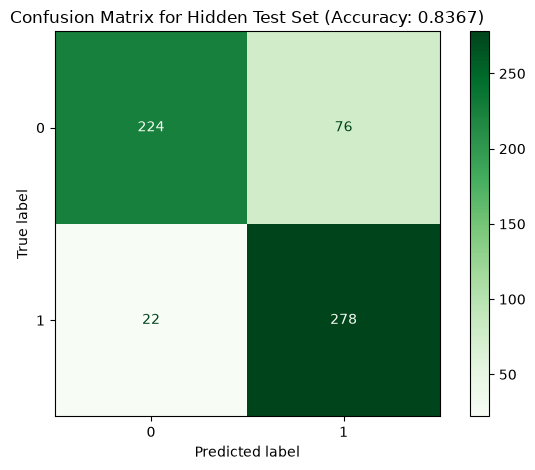

In [6]:
# confusion matrix from saved: hidden_test_with_labels.csv (columns: id, predicted_label)
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

if not os.path.exists("hidden_test_predictions.csv"):
    print("Skip: run the prediction/export cell first to create hidden_test_predictions.csv.")
else:
    df_test_raw = pd.read_csv("hidden_test_with_labels.csv")
    df_predictions = pd.read_csv("hidden_test_predictions.csv")
    title = f"Confusion Matrix for Hidden Test Set (Accuracy: {accuracy_score(df_test_raw['label'], df_predictions['predicted_label']):.4f})"
    y_true = df_test_raw["label"]
    y_pred = df_predictions["predicted_label"]

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Greens")
    disp.ax_.set_title(title)
    plt.tight_layout()
    plt.show()


# AI-Use Section and References

Include:   
* Your representative prompts;  
* An explanation of how you verified the correctness of the suggested solutions.  

*No prompts were used for Stage 2. Copilot inline suggestions were used in VS Code to correct minor syntax errors and improve coding efficiency.*

## References

* Mazzoni, C. (2021, May 21). Augment Your Small Dataset Using Transformers and Synonym Replacement for Sentiment Analysis. *Towards Data Science.* 
* Thonikkadavan, A. (2025, Dec 21). Sentiment Analysis on Imbalanced Datasets: Lessons From Data Augmentation. *Medium.*   